In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Seed:", SEED)

Device: cpu
Seed: 42


In [3]:
X20_train = np.load(
    "X_train_20step.npy",
    mmap_mode="r"
)

y20_train = np.load(
    "y_train_20step.npy",
    mmap_mode="r"
)

X20_val = np.load(
    "X_val_20step.npy",
    mmap_mode="r"
)

y20_val = np.load(
    "y_val_20step.npy",
    mmap_mode="r"
)

X20_test = np.load(
    "X_test_20step.npy",
    mmap_mode="r"
)

y20_test = np.load(
    "y_test_20step.npy",
    mmap_mode="r"
)

print("20-step tensors:")
print("Train:", X20_train.shape, y20_train.shape)
print("Val  :", X20_val.shape, y20_val.shape)
print("Test :", X20_test.shape, y20_test.shape)

20-step tensors:
Train: (44325, 20, 105) (44325,)
Val  : (9655, 20, 105) (9655,)
Test : (10075, 20, 105) (10075,)


In [4]:
operational = pd.read_csv(
    "train_operational_readouts.csv"
)

tte = pd.read_csv(
    "train_tte.csv"
)

print("Operational shape:", operational.shape)
print("TTE shape:", tte.shape)

Operational shape: (1122452, 107)
TTE shape: (23550, 3)


In [5]:
df = operational.merge(
    tte,
    on="vehicle_id",
    how="left",
    validate="many_to_one"
)

df["RUL"] = (
    df["length_of_study_time_step"]
    - df["time_step"]
)

print("Merged shape:", df.shape)

print(
    "Event vehicles:",
    (tte["in_study_repair"] == 1).sum()
)

print(
    "Censored vehicles:",
    (tte["in_study_repair"] == 0).sum()
)

Merged shape: (1122452, 110)
Event vehicles: 2272
Censored vehicles: 21278


In [6]:
event_df = df[
    df["in_study_repair"] == 1
].copy()

event_df = event_df[
    event_df["RUL"] >= 0
].copy()

event_df = event_df.sort_values(
    ["vehicle_id", "time_step"]
).reset_index(drop=True)

print("Event observations:", len(event_df))
print("Event vehicles:", event_df["vehicle_id"].nunique())

Event observations: 105852
Event vehicles: 2272


In [7]:
excluded_columns = [
    "vehicle_id",
    "time_step",
    "length_of_study_time_step",
    "in_study_repair",
    "RUL"
]

feature_columns = [
    c for c in event_df.columns
    if c not in excluded_columns
    and pd.api.types.is_numeric_dtype(event_df[c])
]

print("Number of features:", len(feature_columns))

print("\nFeature list:")
print(feature_columns)

Number of features: 105

Feature list:
['171_0', '666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3', '167_4', '167_5', '167_6', '167_7', '167_8', '167_9', '309_0', '272_0', '272_1', '272_2', '272_3', '272_4', '272_5', '272_6', '272_7', '272_8', '272_9', '835_0', '370_0', '291_0', '291_1', '291_2', '291_3', '291_4', '291_5', '291_6', '291_7', '291_8', '291_9', '291_10', '158_0', '158_1', '158_2', '158_3', '158_4', '158_5', '158_6', '158_7', '158_8', '158_9', '100_0', '459_0', '459_1', '459_2', '459_3', '459_4', '459_5', '459_6', '459_7', '459_8', '459_9', '459_10', '459_11', '459_12', '459_13', '459_14', '459_15', '459_16', '459_17', '459_18', '459_19', '397_0', '397_1', '397_2', '397_3', '397_4', '397_5', '397_6', '397_7', '397_8', '397_9', '397_10', '397_11', '397_12', '397_13', '397_14', '397_15', '397_16', '397_17', '397_18', '397_19', '397_20', '397_21', '397_22', '397_23', '397_24', '397_25', '397_26', '397_27', '397_28', '397_29', '397_30', '397_31', '397_32', '397_33'

In [8]:
from sklearn.model_selection import train_test_split

vehicle_info = (
    tte[[
        "vehicle_id",
        "in_study_repair"
    ]]
    .drop_duplicates("vehicle_id")
)

train_val_ids, test_ids = train_test_split(
    vehicle_info["vehicle_id"],
    test_size=0.15,
    random_state=42,
    stratify=vehicle_info["in_study_repair"]
)

train_info = vehicle_info[
    vehicle_info["vehicle_id"].isin(train_val_ids)
].copy()

train_ids, val_ids = train_test_split(
    train_info["vehicle_id"],
    test_size=0.17647058823529413,
    random_state=42,
    stratify=train_info["in_study_repair"]
)

print("Train vehicles:", len(train_ids))
print("Val vehicles  :", len(val_ids))
print("Test vehicles :", len(test_ids))

Train vehicles: 16484
Val vehicles  : 3533
Test vehicles : 3533


In [9]:
print(
    "\nExpected previous split:"
)

print("Train:", 16485)
print("Val  :", 3532)
print("Test :", 3533)

print(
    "\nCurrent split:"
)

print("Train:", len(train_ids))
print("Val  :", len(val_ids))
print("Test :", len(test_ids))


Expected previous split:
Train: 16485
Val  : 3532
Test : 3533

Current split:
Train: 16484
Val  : 3533
Test : 3533


In [10]:
from sklearn.model_selection import train_test_split

vehicle_info = (
    tte[
        ["vehicle_id", "in_study_repair"]
    ]
    .drop_duplicates("vehicle_id")
    .reset_index(drop=True)
)

# --------------------------------------------------
# EXACT VEHICLE COUNTS REQUIRED
# --------------------------------------------------
N_TEST = 3533
N_VAL = 3532

# First: fixed 3533 test vehicles
train_val_ids, test_ids = train_test_split(
    vehicle_info["vehicle_id"].to_numpy(),
    test_size=N_TEST,
    random_state=42,
    stratify=vehicle_info["in_study_repair"]
)

# Second: fixed 3532 validation vehicles
train_val_info = vehicle_info[
    vehicle_info["vehicle_id"].isin(train_val_ids)
].copy()

train_ids, val_ids = train_test_split(
    train_val_info["vehicle_id"].to_numpy(),
    test_size=N_VAL,
    random_state=42,
    stratify=train_val_info["in_study_repair"]
)

print("Expected previous split:")
print("Train:", 16485)
print("Val  :", 3532)
print("Test :", 3533)

print("\nCurrent split:")
print("Train:", len(train_ids))
print("Val  :", len(val_ids))
print("Test :", len(test_ids))

Expected previous split:
Train: 16485
Val  : 3532
Test : 3533

Current split:
Train: 16485
Val  : 3532
Test : 3533


In [11]:
print("\nEvent vehicles in each split:")

print(
    "Train:",
    train_info[
        train_info["vehicle_id"].isin(train_ids)
    ]["in_study_repair"].sum()
    if "train_info" in globals()
    else vehicle_info[
        vehicle_info["vehicle_id"].isin(train_ids)
    ]["in_study_repair"].sum()
)

print(
    "Val:",
    vehicle_info[
        vehicle_info["vehicle_id"].isin(val_ids)
    ]["in_study_repair"].sum()
)

print(
    "Test:",
    vehicle_info[
        vehicle_info["vehicle_id"].isin(test_ids)
    ]["in_study_repair"].sum()
)


Event vehicles in each split:
Train: 1590
Val: 341
Test: 341


In [12]:
train_df = event_df[
    event_df["vehicle_id"].isin(train_ids)
].copy()

val_df = event_df[
    event_df["vehicle_id"].isin(val_ids)
].copy()

test_df = event_df[
    event_df["vehicle_id"].isin(test_ids)
].copy()

print("Train event rows:", len(train_df))
print("Val event rows  :", len(val_df))
print("Test event rows :", len(test_df))

Train event rows: 74076
Val event rows  : 16056
Test event rows : 15720


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(
    strategy="median"
)

scaler = StandardScaler()

train_features = imputer.fit_transform(
    train_df[feature_columns]
)

val_features = imputer.transform(
    val_df[feature_columns]
)

test_features = imputer.transform(
    test_df[feature_columns]
)

train_features = scaler.fit_transform(
    train_features
)

val_features = scaler.transform(
    val_features
)

test_features = scaler.transform(
    test_features
)

print("Scaled shapes:")
print(train_features.shape)
print(val_features.shape)
print(test_features.shape)

Scaled shapes:
(74076, 105)
(16056, 105)
(15720, 105)


In [14]:
def create_sequences(
    dataframe,
    scaled_features,
    sequence_length
):
    X_sequences = []
    y_sequences = []

    start = 0

    for vehicle_id, group in dataframe.groupby(
        "vehicle_id",
        sort=False
    ):

        n = len(group)

        vehicle_features = scaled_features[
            start:start + n
        ]

        vehicle_target = group["RUL"].to_numpy()

        if n >= sequence_length:

            for i in range(
                sequence_length - 1,
                n
            ):

                X_sequences.append(
                    vehicle_features[
                        i - sequence_length + 1:i + 1
                    ]
                )

                y_sequences.append(
                    vehicle_target[i]
                )

        start += n

    return (
        np.asarray(
            X_sequences,
            dtype=np.float32
        ),
        np.asarray(
            y_sequences,
            dtype=np.float32
        )
    )

In [15]:
sequence_lengths = [10, 40]

sequence_data = {}

for seq_len in sequence_lengths:

    print(
        f"\nGenerating {seq_len}-step sequences..."
    )

    X_train, y_train = create_sequences(
        train_df,
        train_features,
        seq_len
    )

    X_val, y_val = create_sequences(
        val_df,
        val_features,
        seq_len
    )

    X_test, y_test = create_sequences(
        test_df,
        test_features,
        seq_len
    )

    sequence_data[seq_len] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
    }

    print(
        "Train:",
        X_train.shape,
        y_train.shape
    )

    print(
        "Val:",
        X_val.shape,
        y_val.shape
    )

    print(
        "Test:",
        X_test.shape,
        y_test.shape
    )


Generating 10-step sequences...
Train: (59815, 10, 105) (59815,)
Val: (13003, 10, 105) (13003,)
Test: (12667, 10, 105) (12667,)

Generating 40-step sequences...
Train: (21128, 40, 105) (21128,)
Val: (4675, 40, 105) (4675,)
Test: (4461, 40, 105) (4461,)


In [16]:
sequence_data[20] = {
    "X_train": X20_train,
    "y_train": y20_train,
    "X_val": X20_val,
    "y_val": y20_val,
    "X_test": X20_test,
    "y_test": y20_test
}

print("20-step dataset added.")

20-step dataset added.


In [17]:
for seq_len, data in sequence_data.items():

    np.save(
        f"X_train_{seq_len}step_experiment.npy",
        data["X_train"]
    )

    np.save(
        f"y_train_{seq_len}step_experiment.npy",
        data["y_train"]
    )

    np.save(
        f"X_val_{seq_len}step_experiment.npy",
        data["X_val"]
    )

    np.save(
        f"y_val_{seq_len}step_experiment.npy",
        data["y_val"]
    )

    np.save(
        f"X_test_{seq_len}step_experiment.npy",
        data["X_test"]
    )

    np.save(
        f"y_test_{seq_len}step_experiment.npy",
        data["y_test"]
    )

print("All sequence datasets saved.")

All sequence datasets saved.


In [18]:
class RULSequenceDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        X_item = torch.tensor(
            self.X[idx],
            dtype=torch.float32
        )

        y_item = torch.tensor(
            self.y[idx],
            dtype=torch.float32
        )

        return X_item, y_item

In [19]:
class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size=105,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        last_output = output[:, -1, :]

        prediction = self.regressor(
            last_output
        )

        return prediction.squeeze(1)

In [20]:
def train_lstm(
    X_train,
    y_train,
    X_val,
    y_val,
    sequence_length,
    seed=42
):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_dataset = RULSequenceDataset(
        X_train,
        y_train
    )

    val_dataset = RULSequenceDataset(
        X_val,
        y_val
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0
    )

    model = LSTMRegressor(
        input_size=105,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ).to(device)

    y_mean = float(
        np.mean(y_train)
    )

    y_std = float(
        np.std(y_train)
    )

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-5
    )

    best_val_loss = float("inf")
    patience_counter = 0

    EPOCHS = 25
    PATIENCE = 5

    history = []

    best_state = None

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):

        model.train()

        train_loss_total = 0.0
        train_count = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)

            y_scaled = (
                (y_batch.numpy() - y_mean)
                / y_std
            )

            y_scaled = torch.tensor(
                y_scaled,
                dtype=torch.float32,
                device=device
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            predictions = model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_scaled
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            batch_size = X_batch.size(0)

            train_loss_total += (
                loss.item() * batch_size
            )

            train_count += batch_size

        train_loss = (
            train_loss_total
            / train_count
        )

        # Validation
        model.eval()

        val_loss_total = 0.0
        val_count = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)

                y_scaled = (
                    (y_batch.numpy() - y_mean)
                    / y_std
                )

                y_scaled = torch.tensor(
                    y_scaled,
                    dtype=torch.float32,
                    device=device
                )

                predictions = model(
                    X_batch
                )

                loss = criterion(
                    predictions,
                    y_scaled
                )

                batch_size = X_batch.size(0)

                val_loss_total += (
                    loss.item() * batch_size
                )

                val_count += batch_size

        val_loss = (
            val_loss_total
            / val_count
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "sequence_length": sequence_length,
            "seed": seed
        })

        print(
            f"Seq {sequence_length} | "
            f"Epoch {epoch:02d} | "
            f"Train: {train_loss:.5f} | "
            f"Val: {val_loss:.5f}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        else:

            patience_counter += 1

            if patience_counter >= PATIENCE:
                print("Early stopping.")
                break

    training_time = time.time() - start_time

    model.load_state_dict(
        best_state
    )

    return (
        model,
        y_mean,
        y_std,
        pd.DataFrame(history),
        training_time
    )

In [21]:
def evaluate_lstm(
    model,
    X_test,
    y_test,
    y_mean,
    y_std
):

    test_dataset = RULSequenceDataset(
        X_test,
        y_test
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0
    )

    predictions = []
    actuals = []

    model.eval()

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            pred_scaled = model(
                X_batch
            )

            pred = (
                pred_scaled.cpu().numpy()
                * y_std
                + y_mean
            )

            predictions.extend(pred)
            actuals.extend(
                y_batch.numpy()
            )

    actuals = np.asarray(actuals)
    predictions = np.asarray(predictions)

    mae = mean_absolute_error(
        actuals,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actuals,
            predictions
        )
    )

    r2 = r2_score(
        actuals,
        predictions
    )

    return (
        mae,
        rmse,
        r2,
        actuals,
        predictions
    )

In [22]:
results = []
all_histories = {}

for seq_len in [10, 20, 40]:

    print("\n" + "=" * 60)
    print(
        f"TRAINING LSTM WITH {seq_len}-STEP SEQUENCES"
    )
    print("=" * 60)

    data = sequence_data[seq_len]

    model, y_mean, y_std, history, training_time = (
        train_lstm(
            data["X_train"],
            data["y_train"],
            data["X_val"],
            data["y_val"],
            sequence_length=seq_len,
            seed=42
        )
    )

    (
        mae,
        rmse,
        r2,
        actuals,
        predictions
    ) = evaluate_lstm(
        model,
        data["X_test"],
        data["y_test"],
        y_mean,
        y_std
    )

    results.append({
        "Sequence_Length": seq_len,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training_Time_Min": training_time / 60
    })

    all_histories[seq_len] = history

    torch.save(
        model.state_dict(),
        f"best_lstm_{seq_len}step.pt"
    )

    print(
        f"\nRESULT — {seq_len} steps"
    )

    print(
        f"MAE  : {mae:.4f}"
    )

    print(
        f"RMSE : {rmse:.4f}"
    )

    print(
        f"R²   : {r2:.4f}"
    )


TRAINING LSTM WITH 10-STEP SEQUENCES
Seq 10 | Epoch 01 | Train: 0.53755 | Val: 0.81298
Seq 10 | Epoch 02 | Train: 0.36248 | Val: 0.81473
Seq 10 | Epoch 03 | Train: 0.28493 | Val: 0.84596
Seq 10 | Epoch 04 | Train: 0.23697 | Val: 0.88309
Seq 10 | Epoch 05 | Train: 0.20348 | Val: 0.90023
Seq 10 | Epoch 06 | Train: 0.18068 | Val: 0.93422
Early stopping.

RESULT — 10 steps
MAE  : 46.8298
RMSE : 61.0813
R²   : 0.3026

TRAINING LSTM WITH 20-STEP SEQUENCES
Seq 20 | Epoch 01 | Train: 0.54637 | Val: 0.72688
Seq 20 | Epoch 02 | Train: 0.32207 | Val: 0.84407
Seq 20 | Epoch 03 | Train: 0.23179 | Val: 0.92350
Seq 20 | Epoch 04 | Train: 0.17848 | Val: 0.97720
Seq 20 | Epoch 05 | Train: 0.14316 | Val: 0.91655
Seq 20 | Epoch 06 | Train: 0.11814 | Val: 0.95103
Early stopping.

RESULT — 20 steps
MAE  : 44.9808
RMSE : 60.6743
R²   : 0.2307

TRAINING LSTM WITH 40-STEP SEQUENCES
Seq 40 | Epoch 01 | Train: 0.56945 | Val: 1.36994
Seq 40 | Epoch 02 | Train: 0.27254 | Val: 1.31170
Seq 40 | Epoch 03 | Train: 0

In [23]:
sequence_results = pd.DataFrame(
    results
)

display(
    sequence_results.round(4)
)

sequence_results.to_csv(
    "sequence_length_comparison.csv",
    index=False
)

print(
    "Saved: sequence_length_comparison.csv"
)

,Sequence_Length,MAE,RMSE,R2,Training_Time_Min
0,10,46.8298,61.0813,0.3026,0.8114
1,20,44.9808,60.6743,0.2307,0.9055
2,40,38.8519,51.4434,0.2018,0.8629


Saved: sequence_length_comparison.csv


In [24]:
history_df = pd.concat(
    all_histories.values(),
    ignore_index=True
)

history_df.to_csv(
    "sequence_length_training_histories.csv",
    index=False
)

print(
    "Saved: sequence_length_training_histories.csv"
)

Saved: sequence_length_training_histories.csv


In [25]:
config = {
    "seed": 42,
    "sequence_lengths": [10, 20, 40],
    "input_features": 105,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "max_epochs": 25,
    "early_stopping_patience": 5,
    "loss_function": "MSELoss",
    "optimizer": "Adam",
    "gradient_clip_norm": 1.0,
    "train_split": 0.70,
    "validation_split": 0.15,
    "test_split": 0.15
}

config_df = pd.DataFrame(
    list(config.items()),
    columns=["Parameter", "Value"]
)

config_df.to_csv(
    "sequence_length_experiment_config.csv",
    index=False
)

display(config_df)

,Parameter,Value
0,seed,42
1,sequence_lengths,"[10, 20, 40]"
2,input_features,105
3,hidden_size,64
4,num_layers,2
5,dropout,0.2
6,batch_size,128
7,learning_rate,0.001
8,weight_decay,0.00001
9,max_epochs,25


In [26]:
# Generate 20-step sequences using the SAME split
# as the 10-step and 40-step experiments

X_train_20, y_train_20 = create_sequences(
    train_df,
    train_features,
    20
)

X_val_20, y_val_20 = create_sequences(
    val_df,
    val_features,
    20
)

X_test_20, y_test_20 = create_sequences(
    test_df,
    test_features,
    20
)

sequence_data[20] = {
    "X_train": X_train_20,
    "y_train": y_train_20,
    "X_val": X_val_20,
    "y_val": y_val_20,
    "X_test": X_test_20,
    "y_test": y_test_20
}

print("20-step sequences regenerated using the same experiment split.")

print("Train:", X_train_20.shape, y_train_20.shape)
print("Val  :", X_val_20.shape, y_val_20.shape)
print("Test :", X_test_20.shape, y_test_20.shape)

20-step sequences regenerated using the same experiment split.
Train: (44795, 20, 105) (44795,)
Val  : (9810, 20, 105) (9810,)
Test : (9450, 20, 105) (9450,)


In [27]:
for seq_len, data in sequence_data.items():

    np.save(
        f"X_train_{seq_len}step_experiment.npy",
        data["X_train"]
    )

    np.save(
        f"y_train_{seq_len}step_experiment.npy",
        data["y_train"]
    )

    np.save(
        f"X_val_{seq_len}step_experiment.npy",
        data["X_val"]
    )

    np.save(
        f"y_val_{seq_len}step_experiment.npy",
        data["y_val"]
    )

    np.save(
        f"X_test_{seq_len}step_experiment.npy",
        data["X_test"]
    )

    np.save(
        f"y_test_{seq_len}step_experiment.npy",
        data["y_test"]
    )

print("All 10, 20 and 40-step sequence datasets saved successfully.")

All 10, 20 and 40-step sequence datasets saved successfully.


In [28]:
results = []
all_histories = {}

for seq_len in [10, 20, 40]:

    print("\n" + "=" * 60)
    print(f"TRAINING LSTM WITH {seq_len}-STEP SEQUENCES")
    print("=" * 60)

    data = sequence_data[seq_len]

    model, y_mean, y_std, history, training_time = train_lstm(
        data["X_train"],
        data["y_train"],
        data["X_val"],
        data["y_val"],
        sequence_length=seq_len,
        seed=42
    )

    (
        mae,
        rmse,
        r2,
        actuals,
        predictions
    ) = evaluate_lstm(
        model,
        data["X_test"],
        data["y_test"],
        y_mean,
        y_std
    )

    results.append({
        "Sequence_Length": seq_len,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training_Time_Min": training_time / 60
    })

    all_histories[seq_len] = history

    torch.save(
        model.state_dict(),
        f"FINAL_best_lstm_{seq_len}step.pt"
    )

    print(f"\nRESULT — {seq_len} steps")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


TRAINING LSTM WITH 10-STEP SEQUENCES
Seq 10 | Epoch 01 | Train: 0.53755 | Val: 0.81298
Seq 10 | Epoch 02 | Train: 0.36248 | Val: 0.81473
Seq 10 | Epoch 03 | Train: 0.28493 | Val: 0.84596
Seq 10 | Epoch 04 | Train: 0.23697 | Val: 0.88309
Seq 10 | Epoch 05 | Train: 0.20348 | Val: 0.90023
Seq 10 | Epoch 06 | Train: 0.18068 | Val: 0.93422
Early stopping.

RESULT — 10 steps
MAE  : 46.8298
RMSE : 61.0813
R²   : 0.3026

TRAINING LSTM WITH 20-STEP SEQUENCES
Seq 20 | Epoch 01 | Train: 0.54163 | Val: 0.94657
Seq 20 | Epoch 02 | Train: 0.32544 | Val: 0.94471
Seq 20 | Epoch 03 | Train: 0.22770 | Val: 1.03908
Seq 20 | Epoch 04 | Train: 0.17342 | Val: 1.06167
Seq 20 | Epoch 05 | Train: 0.13592 | Val: 1.03814
Seq 20 | Epoch 06 | Train: 0.11395 | Val: 1.03206
Seq 20 | Epoch 07 | Train: 0.09797 | Val: 1.10316
Early stopping.

RESULT — 20 steps
MAE  : 44.1436
RMSE : 58.8849
R²   : 0.2148

TRAINING LSTM WITH 40-STEP SEQUENCES
Seq 40 | Epoch 01 | Train: 0.56945 | Val: 1.36994
Seq 40 | Epoch 02 | Train: 0

In [29]:
sequence_results_final = pd.DataFrame(results)

display(
    sequence_results_final.round(4)
)

sequence_results_final.to_csv(
    "FINAL_sequence_length_comparison.csv",
    index=False
)

print(
    "Saved: FINAL_sequence_length_comparison.csv"
)

,Sequence_Length,MAE,RMSE,R2,Training_Time_Min
0,10,46.8298,61.0813,0.3026,0.8018
1,20,44.1436,58.8849,0.2148,1.1320
2,40,38.8519,51.4434,0.2018,0.8811


Saved: FINAL_sequence_length_comparison.csv


In [30]:
history_df = pd.concat(
    all_histories.values(),
    ignore_index=True
)

history_df.to_csv(
    "FINAL_sequence_length_training_histories.csv",
    index=False
)

print(
    "Saved: FINAL_sequence_length_training_histories.csv"
)

display(history_df.head(10))

Saved: FINAL_sequence_length_training_histories.csv


,epoch,train_loss,val_loss,sequence_length,seed
0,1,0.537546,0.812977,10,42
1,2,0.362476,0.814732,10,42
2,3,0.284925,0.845960,10,42
3,4,0.236969,0.883086,10,42
4,5,0.203478,0.900234,10,42
5,6,0.180677,0.934218,10,42
6,1,0.541631,0.946569,20,42
7,2,0.325439,0.944707,20,42
8,3,0.227702,1.039084,20,42
9,4,0.173423,1.061667,20,42


In [31]:
config_df = pd.DataFrame(
    list(config.items()),
    columns=["Parameter", "Value"]
)

config_df.to_csv(
    "FINAL_sequence_length_experiment_config.csv",
    index=False
)

print("Saved: FINAL_sequence_length_experiment_config.csv")
display(config_df)

Saved: FINAL_sequence_length_experiment_config.csv


,Parameter,Value
0,seed,42
1,sequence_lengths,"[10, 20, 40]"
2,input_features,105
3,hidden_size,64
4,num_layers,2
5,dropout,0.2
6,batch_size,128
7,learning_rate,0.001
8,weight_decay,0.00001
9,max_epochs,25


In [33]:
from pathlib import Path
import numpy as np

print("========== SEQUENCE FILE AUDIT ==========\n")

files = sorted(Path(".").glob("X_*step*.npy"))

for f in files:
    try:
        arr = np.load(f, mmap_mode="r")
        print(f"{f.name:45s} -> {arr.shape}")
    except Exception as e:
        print(f"{f.name:45s} -> ERROR: {e}")

========== SEQUENCE FILE AUDIT ==========

X_test_10step_experiment.npy                  -> (12667, 10, 105)
X_test_20step.npy                             -> (10075, 20, 105)
X_test_20step_experiment.npy                  -> (9450, 20, 105)
X_test_40step_experiment.npy                  -> (4461, 40, 105)
X_train_10step_experiment.npy                 -> (59815, 10, 105)
X_train_20step.npy                            -> (44325, 20, 105)
X_train_20step_experiment.npy                 -> (44795, 20, 105)
X_train_40step_experiment.npy                 -> (21128, 40, 105)
X_val_10step_experiment.npy                   -> (13003, 10, 105)
X_val_20step.npy                              -> (9655, 20, 105)
X_val_20step_experiment.npy                   -> (9810, 20, 105)
X_val_40step_experiment.npy                   -> (4675, 40, 105)


In [34]:
import os
import numpy as np
import pandas as pd

print("========== TASK 7 FINAL CHECK ==========\n")

sequence_lengths = [10, 20, 40]

# Check X/y files and collect actual shapes
shape_rows = []

for seq_len in sequence_lengths:
    X_train = np.load(f"X_train_{seq_len}step_experiment.npy", mmap_mode="r")
    y_train = np.load(f"y_train_{seq_len}step_experiment.npy", mmap_mode="r")

    X_val = np.load(f"X_val_{seq_len}step_experiment.npy", mmap_mode="r")
    y_val = np.load(f"y_val_{seq_len}step_experiment.npy", mmap_mode="r")

    X_test = np.load(f"X_test_{seq_len}step_experiment.npy", mmap_mode="r")
    y_test = np.load(f"y_test_{seq_len}step_experiment.npy", mmap_mode="r")

    # Basic consistency checks
    assert X_train.shape[0] == y_train.shape[0]
    assert X_val.shape[0] == y_val.shape[0]
    assert X_test.shape[0] == y_test.shape[0]

    assert X_train.shape[1:] == (seq_len, 105)
    assert X_val.shape[1:] == (seq_len, 105)
    assert X_test.shape[1:] == (seq_len, 105)

    shape_rows.append({
        "Sequence_Length": seq_len,
        "Train": X_train.shape[0],
        "Validation": X_val.shape[0],
        "Test": X_test.shape[0]
    })

shape_df = pd.DataFrame(shape_rows)

print("Sequence datasets:")
display(shape_df)

print("Sequence tensor checks: PASS")

# Check final metrics
results = pd.read_csv("FINAL_sequence_length_comparison.csv")

print("\nFinal metrics:")
display(results)

assert results["Sequence_Length"].tolist() == [10, 20, 40]
assert len(results) == 3

print("Metric checks: PASS")

# Check histories
history_df = pd.read_csv(
    "FINAL_sequence_length_training_histories.csv"
)

assert sorted(history_df["sequence_length"].unique()) == [10, 20, 40]

print("\nTraining-history check: PASS")

# Check configuration
config_df = pd.read_csv(
    "FINAL_sequence_length_experiment_config.csv"
)

print("Configuration check: PASS")

# Check model files
model_files = [
    "FINAL_best_lstm_10step.pt",
    "FINAL_best_lstm_20step.pt",
    "FINAL_best_lstm_40step.pt"
]

for f in model_files:
    assert os.path.exists(f)

print("Model checkpoint check: PASS")

print("\n✅ TASK 7 LOCKED SUCCESSFULLY")

========== TASK 7 FINAL CHECK ==========

Sequence datasets:


,Sequence_Length,Train,Validation,Test
0,10,59815,13003,12667
1,20,44795,9810,9450
2,40,21128,4675,4461


Sequence tensor checks: PASS

Final metrics:


,Sequence_Length,MAE,RMSE,R2,Training_Time_Min
0,10,46.829796,61.081305,0.302644,0.801774
1,20,44.143620,58.884875,0.214766,1.131951
2,40,38.851864,51.443421,0.201832,0.881144


Metric checks: PASS

Training-history check: PASS
Configuration check: PASS
Model checkpoint check: PASS

✅ TASK 7 LOCKED SUCCESSFULLY


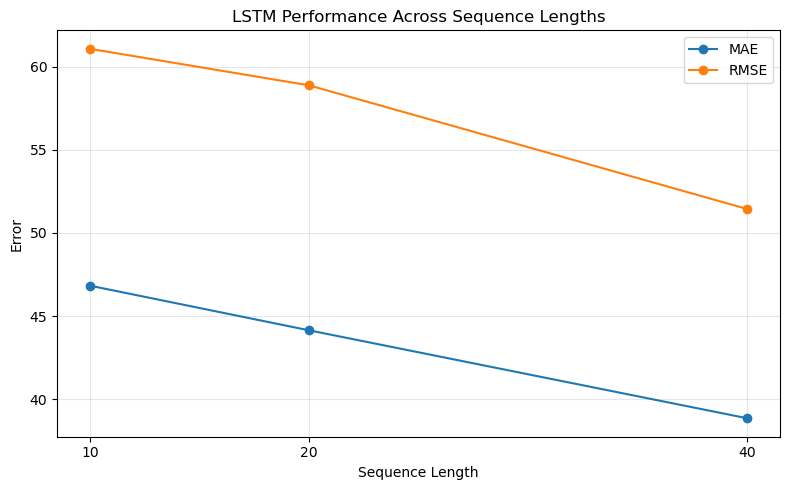

Saved: TASK7_sequence_length_comparison.png


In [35]:
# ============================================================
# TASK 7 — SAVE SEQUENCE LENGTH COMPARISON FIGURE
# ============================================================

import matplotlib.pyplot as plt

# Use the final results already obtained
seq_plot_df = pd.DataFrame({
    "Sequence Length": [10, 20, 40],
    "MAE": [46.829796, 44.143620, 38.851864],
    "RMSE": [61.081305, 58.884875, 51.443421],
    "R2": [0.302644, 0.214766, 0.201832]
})

plt.figure(figsize=(8, 5))
plt.plot(seq_plot_df["Sequence Length"], seq_plot_df["MAE"],
         marker="o", label="MAE")
plt.plot(seq_plot_df["Sequence Length"], seq_plot_df["RMSE"],
         marker="o", label="RMSE")

plt.xlabel("Sequence Length")
plt.ylabel("Error")
plt.title("LSTM Performance Across Sequence Lengths")
plt.xticks([10, 20, 40])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "TASK7_sequence_length_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: TASK7_sequence_length_comparison.png")